# Подготовка окружения

In [23]:
!pip install "dask[complete]" graphviz

In [24]:
import sys
import os
import pandas as pd
import dask.dataframe as dd
import dask.delayed as delayed
from dask.distributed import Client
from dask.diagnostics import ProgressBar

# Инициализация клиента Dask (Оптимизированные настройки без жесткого лимита памяти)
client = Client(n_workers=2, threads_per_worker=2, processes=True)
client

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37535 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39413
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:37535/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34631'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46595'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40835 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40835
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:36144
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:43497 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:43497
IN

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:37535/status,
Dashboard: http://127.0.0.1:37535/status,Workers: 2
Total threads: 4,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39413,Workers: 0
Dashboard: http://127.0.0.1:37535/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40835,Total threads: 2
Dashboard: http://127.0.0.1:33511/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:34631,


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
cd /content/drive/MyDrive/etl

/content/drive/MyDrive/etl


In [27]:
ls

austin_housing_contrast.csv  cleaned_data.csv
austinHousingData.csv        cleaned_dataset.parquet/


# Шаг 1. Extract (Извлечение данных)

In [28]:
df = dd.read_csv('austin_housing_contrast.csv',  dtype={'zipcode': 'object', 'latest_saledate': 'object', 'homeImage': 'object'})
df

,zpid,city,zipcode,streetAddress,latitude,longitude,propertyTaxRate,garageSpaces,hasGarage,parkingSpaces,hasCooling,hasHeating,hasAssociation,hasSpa,hasView,homeType,livingAreaSqFt,yearBuilt,latestPrice,numPriceChanges,description,latest_saleyear,latest_salemonth,latest_saledate,latestPriceSource,numOfPhotos,numOfParkingFeatures,numOfWindowFeatures,numOfPatioAndPorchFeatures,numOfSecurityFeatures,numOfWaterfrontFeatures,numOfAccessibilityFeatures,numOfPrimarySchools,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolSize,MedianStudentsPerTeacher,lotSizeSqFt,numOfBedrooms,numOfBathrooms,numOfStories,numOfAppliances,numOfCommunityFeatures,homeImage
npartitions=33,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,string,string,string,float64,float64,float64,int64,bool,int64,bool,bool,bool,bool,bool,string,float64,int64,float64,int64,string,int64,int64,string,string,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,int64,string
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


# Шаг 2. Transform (Трансформация и очистка данных)

In [29]:
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
MedianStudentsPerTeacher    int64
zpid                          ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(6aba527)))).sum()

In [30]:
mysize = df.index.size
missing_count = ((missing_values / mysize) * 100)
missing_count

Dask Series Structure:
npartitions=1
MedianStudentsPerTeacher    float64
zpid                            ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(6aba527)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(6aba527))).size() * 100

In [31]:
with ProgressBar():
  missing_count_percent = missing_count.compute()
missing_count_percent

,0
zpid,0.000000
city,0.000000
zipcode,0.000000
streetAddress,0.000000
latitude,0.000000
longitude,0.000000
propertyTaxRate,0.000000
garageSpaces,0.000000
hasGarage,0.000000
parkingSpaces,0.000000


In [32]:
# 1. Получаем список столбцов для удаления
columns_to_drop = list(missing_count_percent[missing_count_percent > 60].index)
print("Столбцы на удаление:", columns_to_drop)

# 2. Оптимизация. Убираем .compute() и ProgressBar!
df_dropped = df.drop(columns=columns_to_drop)

# 3. Проверка результата
df_dropped.head()

Столбцы на удаление: ['numOfParkingFeatures', 'numOfWindowFeatures', 'numOfPatioAndPorchFeatures', 'numOfSecurityFeatures', 'numOfWaterfrontFeatures', 'numOfAccessibilityFeatures', 'numOfPrimarySchools', 'numOfElementarySchools', 'numOfMiddleSchools', 'numOfHighSchools', 'avgSchoolDistance', 'avgSchoolSize', 'MedianStudentsPerTeacher']


,zpid,city,zipcode,streetAddress,latitude,longitude,propertyTaxRate,garageSpaces,hasGarage,parkingSpaces,...,latest_saledate,latestPriceSource,numOfPhotos,lotSizeSqFt,numOfBedrooms,numOfBathrooms,numOfStories,numOfAppliances,numOfCommunityFeatures,homeImage
0,751174053,austin,78702,5851 Meadow Ln,30.370462,-97.808494,2.008106,0,False,0,...,2019-11-01,Agent Provided,30,100000.0,3,3.0,2,5,3,751174053_b7b0eb0ad0e0ad9c6b447d386ca2bf80.jpg
1,281711358,austin,78723,5582 River Rd,30.437932,-97.696259,2.016555,2,True,2,...,2022-03-13,Agent Provided,29,2000.0,4,4.0,2,5,1,281711358_d1299966bb62154445b8a66254e37d91.jpg
2,252538554,austin,78749,4144 Oak Ave,30.356929,-97.827830,1.968285,2,True,3,...,2022-08-09,Agent Provided,18,100000.0,5,5.0,1,1,2,252538554_dfd4567cb2a0f79847c52581fa78acc6.jpg
3,342884159,austin,78758,4704 Spring St,30.265456,-97.712379,1.985192,2,True,2,...,2024-12-06,Agent Provided,30,100000.0,3,2.0,1,5,1,342884159_bb3617b6bff5bb74d7830ab17a52f47e.jpg
4,746364838,austin,78751,7722 Hill Rd,30.408405,-97.779437,1.990381,3,True,3,...,2018-06-03,Agent Provided,33,2000.0,3,3.0,1,4,2,746364838_4a675252c4df18eb9b6cc5c7687238c4.jpg


# Шаг 3. Load (Сохранение результатов пайплайна)

In [ ]:
df_dropped.to_csv('cleaned_data.csv',
                  single_file=True,
                  index=False)

ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-141442' coro=<Client._gather.<locals>.wait() done, defined at /usr/local/lib/python3.12/dist-packages/distributed/client.py:2388> exception=AllExit()>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/distributed/client.py", line 2397, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

In [33]:
df_dropped.to_parquet('cleaned_dataset.parquet', engine='pyarrow')

# Шаг 4. Визуализация направленных ациклических графов (DAG)

Сначала создадим простой граф, визуализирующий процесс подсчета стоимости всего жилого фонда в датасете

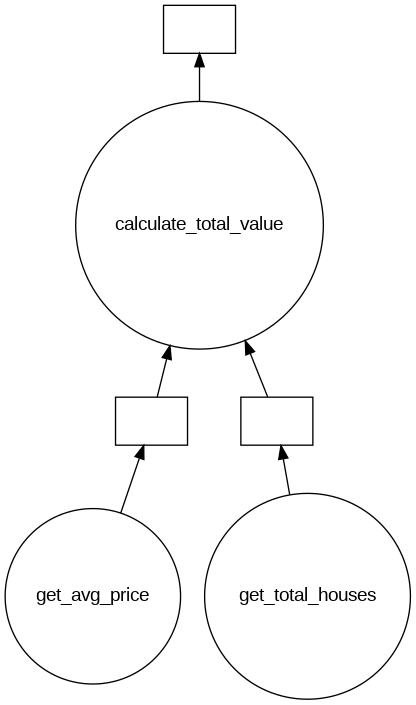

In [ ]:
# Подсчет общего количества домов
def get_total_houses():
    return len(df)

# Подсчет средней цены
def get_avg_price():
    return df['latestPrice'].mean().compute()

# Вычисление стоимости всего жилого фонда
def calculate_total_value(total, avg):
    return total * avg

# Создание отложенных объектов
x = delayed(get_total_houses)()
y = delayed(get_avg_price)()
z = delayed(calculate_total_value)(x, y)

# Визуализация графа
z.visualize(filename='easy_dask.png')

from IPython.display import Image
display(Image('easy_dask.png'))

# Запуск вычислений и получение результата
result = z.compute()

Теперь создадим сложный граф, который отражает процесс проведения расчетов

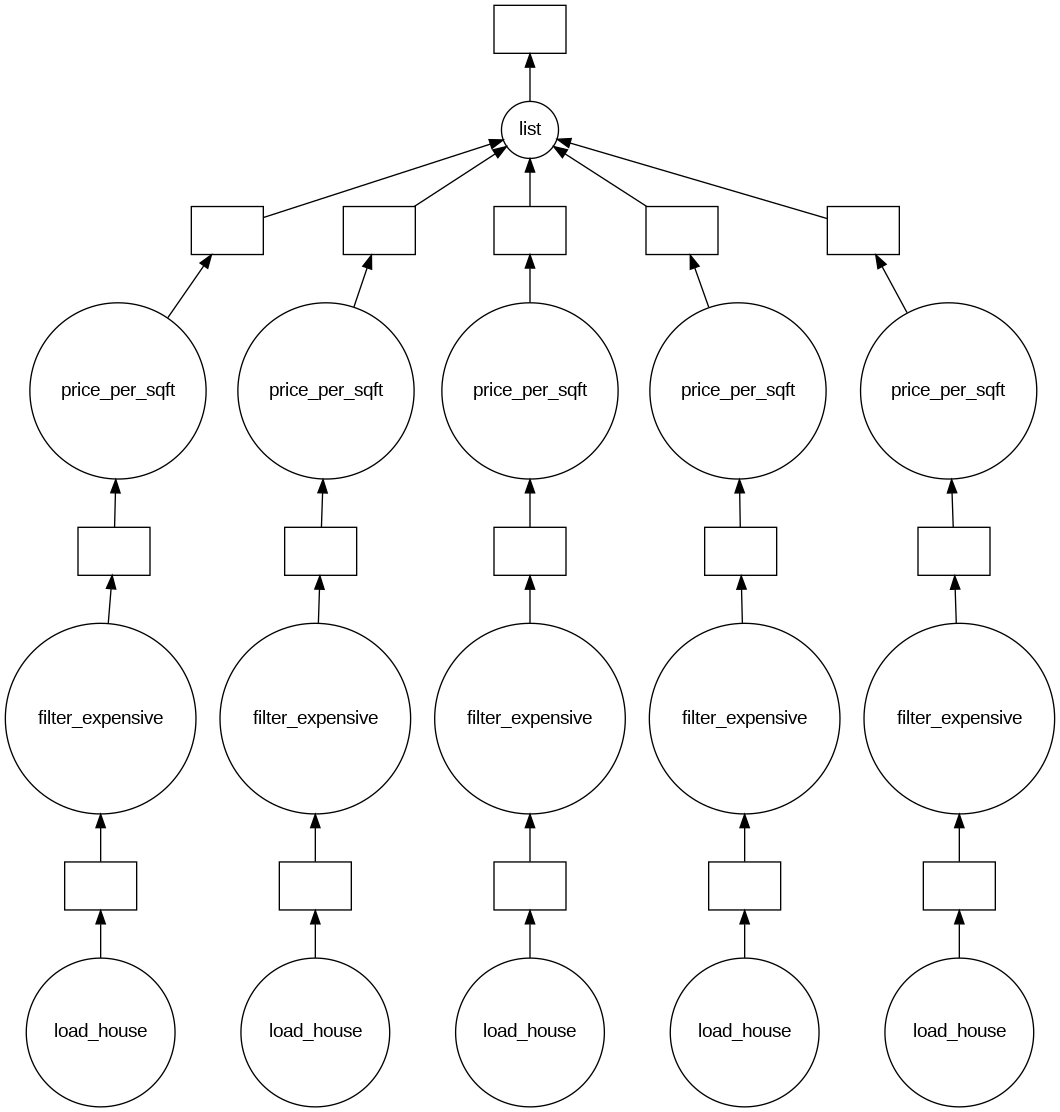

In [ ]:
# Cписок zpid домов
houses = [101, 102, 103, 104, 105]

# Слой 1: Загружаем каждый дом
def load_house(h):
    return f"дом_{h}"

layer1 = [delayed(load_house)(h) for h in houses]

# Слой 2: Проверяем цену
def filter_expensive(house):
    if house['price'] > 500000:
        return house
    return None

layer2 = [delayed(filter_expensive)(h) for h in layer1]

# Слой 3: Считаем площадь
def price_per_sqft(house):
    if house is None:
        return None
    house['price_per_sqft'] = round(house['price'] / house['sqft'], 2)
    return house

layer3 = [delayed(price_per_sqft)(h) for h in layer2]

total = delayed(list)(layer3)

# Визуализация
total.visualize(filename='difficult_dask.png')
display(Image('difficult_dask.png'))

# Анализ датасета

Проведем анализ датасета и создадим дашборд, отражающий ключевые метрики

In [ ]:
import altair as alt
import pandas as pd
import numpy as np

# ФИЛЬТР: оставляем только Austin
df_austin = df_dropped[df_dropped['city'] == 'austin']

# Подготовка данных
df_pd = df[['yearBuilt', 'latest_salemonth', 'homeType', 'latestPrice', 'hasView']].compute()

# Предобработка данных
df_pd['build_decade'] = (df_pd['yearBuilt'] // 10) * 10
df_pd['sale_month'] = pd.to_numeric(df_pd['latest_salemonth'], errors='coerce')
df_pd['view_category'] = df_pd['hasView'].astype(str).map({
    'True': 'Есть вид',
    'False': 'Нет вида'
})

# ГРАФИК 1
decade_data = df_pd[df_pd['build_decade'] > 1900].groupby('build_decade').size().reset_index(name='count')

hover1 = alt.selection_single(on='mouseover', nearest=True, fields=['build_decade'])

chart1 = alt.Chart(decade_data).mark_line(
    point=alt.OverlayMarkDef(color='coral', size=80, filled=True),
    color='coral',
    strokeWidth=3
).encode(
    x=alt.X('build_decade:Q', title='Десятилетие постройки'),
    y=alt.Y('count:Q', title='Количество домов'),
    tooltip=[
        alt.Tooltip('build_decade:Q', title='Десятилетие', format='d'),
        alt.Tooltip('count:Q', title='Количество домов')
    ]
).properties(
    title='Количество домов по десятилетиям постройки',
    width=400,
    height=300
).add_selection(hover1)

# ГРАФИК 2
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

monthly_data = []
for i, month in enumerate(month_names, 1):
    count = len(df_pd[df_pd['sale_month'] == i])
    monthly_data.append({'month': month, 'count': count, 'month_num': i})

monthly_df = pd.DataFrame(monthly_data)

hover2 = alt.selection_single(on='mouseover', nearest=True, fields=['month'])

chart2 = alt.Chart(monthly_df).mark_line(
    point=alt.OverlayMarkDef(color='steelblue', size=80, filled=True),
    color='steelblue',
    strokeWidth=3
).encode(
    x=alt.X('month:N', title='Месяц', sort=month_names),
    y=alt.Y('count:Q', title='Количество продаж'),
    tooltip=[
        alt.Tooltip('month:N', title='Месяц'),
        alt.Tooltip('count:Q', title='Количество продаж')
    ]
).properties(
    title='Количество продаж по месяцам',
    width=400,
    height=300
).add_selection(hover2)

# ГРАФИК 3 - с сортировкой по убыванию цены
top_types = df_pd['homeType'].value_counts().head(6).index.tolist()
type_avg = df_pd[df_pd['homeType'].isin(top_types)].groupby('homeType')['latestPrice'].mean().round(0).reset_index()
type_avg.columns = ['homeType', 'averagePrice']
type_avg = type_avg.sort_values('averagePrice', ascending=False)

# Добавляем интерактивность для третьего графика
hover3 = alt.selection_single(on='mouseover', nearest=True, fields=['homeType'])

chart3 = alt.Chart(type_avg).mark_bar(
    color='lightseagreen'
).encode(
    x=alt.X('homeType:N', title='Тип дома', sort=type_avg['homeType'].tolist()),
    y=alt.Y('averagePrice:Q', title='Средняя цена ($)'),
    tooltip=[
        alt.Tooltip('homeType:N', title='Тип дома'),
        alt.Tooltip('averagePrice:Q', title='Средняя цена', format='$,.0f')
    ]
).properties(
    title='Средняя цена по типам домов',
    width=400,
    height=300
).add_selection(hover3)

# ГРАФИК 4
view_data = df_pd[df_pd['view_category'].isin(['Нет вида', 'Есть вид'])]
view_stats = view_data.groupby('view_category').size().reset_index(name='count')
view_stats['percentage'] = (view_stats['count'] / view_stats['count'].sum() * 100).round(1)

avg_prices = view_data.groupby('view_category')['latestPrice'].mean().round(0).reset_index()
avg_prices.columns = ['view_category', 'avg_price']
view_stats = view_stats.merge(avg_prices, on='view_category')
view_stats['avg_price_formatted'] = view_stats['avg_price'].apply(lambda x: f'${x:,.0f}')

hover4 = alt.selection_single(on='mouseover', fields=['view_category'])

chart4 = alt.Chart(view_stats).mark_arc(
    outerRadius=120
).encode(
    theta=alt.Theta('count:Q'),
    color=alt.Color('view_category:N',
                    scale=alt.Scale(
                        domain=['Есть вид', 'Нет вида'],
                        range=['#FA8072', '#87CEFA']
                    ),
                    legend=None),
    tooltip=[
        alt.Tooltip('view_category:N', title='Категория'),
        alt.Tooltip('count:Q', title='Количество'),
        alt.Tooltip('percentage:Q', title='Процент', format='.1f'),
        alt.Tooltip('avg_price_formatted:N', title='Средняя цена')
    ],
    opacity=alt.condition(hover4, alt.value(1), alt.value(0.7))
).add_selection(hover4).properties(
    title='Распределение по наличию вида',
    width=400,
    height=300
)

# Объединяем
row1 = alt.hconcat(chart1, chart2)
row2 = alt.hconcat(chart3, chart4)
final_chart = alt.vconcat(row1, row2).properties(
    title=alt.TitleParams(
        'Анализ рынка недвижимости Остина',
        fontSize=18,
        anchor='middle',
        offset=25
    )
)

final_chart

/tmp/ipykernel_1804/3317410802.py:22: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  hover1 = alt.selection_single(on='mouseover', nearest=True, fields=['build_decade'])
/tmp/ipykernel_1804/3317410802.py:39: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(hover1)
/tmp/ipykernel_1804/3317410802.py:52: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  hover2 = alt.selection_single(on='mouseover', nearest=True, fields=['month'])
/tmp/ipykernel_1804/3317410802.py:69: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(hover2)
/tmp/ipykernel_1804/3317410802.py:78: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  hover3 = alt.selection_single(on='mouseover', nearest=True, fields=['homeType'])
/tmp/ipykernel_1804/3317410802.py:93: AltairDeprecationWarning: 
Deprecat

alt.VConcatChart(...)